### 키워드

In [5]:
# from collections import Counter
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# def plot_and_save_top_keywords(file_path):
#     # 1. 데이터 로드 및 필터링
#     df = pd.read_csv(file_path)
#     df = df[df['발행연도'] >= 2016]
    
#     # 카테고리 순서 명시적으로 지정
#     categories = ['공법', '민사법', '형사법', '기타']
    
#     # 데이터를 저장할 리스트 초기화
#     csv_data = []
    
#     # 시각화 설정 (2x2 서브플롯)
#     fig, axes = plt.subplots(2, 2, figsize=(15, 12))
#     axes = axes.flatten()
#     plt.rc('font', family='Malgun Gothic') 
    
#     # 제외할 단어 리스트 (비교를 위해 모두 소문자로 작성)
#     exclude_terms = ['인공지능', 'ai', 'artificial intelligence', 'artificial intelligence(ai)']

#     for i, cat in enumerate(categories):
#         # 해당 카테고리의 키워드 추출 및 세척
#         cat_keywords = df[df['분류'] == cat]['키워드'].dropna()
        
#         # 빈 리스트로 초기화
#         raw_keywords = []
#         for keyword_str in cat_keywords:
#             raw_keywords.extend(str(keyword_str).split(','))
        
#         clean_keywords = []
#         for kw in raw_keywords:
#             # [수정] ']]>' 제거, 공백 제거 후 모두 소문자로 변환
#             cleaned = kw.replace(']]>', '').strip().lower()
            
#             # 의미 없는 단어 및 빈 문자열 제외 (소문자로 변환된 단어와 비교)
#             if cleaned and cleaned not in exclude_terms:
#                 clean_keywords.append(cleaned)
        
#         # 2. 빈도 계산 (CSV용으로 상위 50개 추출)
#         keyword_counts = Counter(clean_keywords).most_common(50)
        
#         # CSV 저장을 위한 리스트 추가
#         for word, count in keyword_counts:
#             csv_data.append({
#                 '분류': cat,
#                 '키워드': word,
#                 '빈도': count
#             })
        
#         # 3. 시각화 (차트용으로 상위 10개만 사용)
#         if keyword_counts:
#             top_10 = keyword_counts[:10]
#             words = [x[0] for x in top_10]
#             counts = [x[1] for x in top_10]
            
#             sns.barplot(x=counts, y=words, ax=axes[i], palette='viridis')
#             axes[i].set_title(f'[{cat}] 주요 키워드 TOP 10', fontsize=13)
#             axes[i].set_xlabel('빈도')
#             axes[i].set_ylabel('')

#     # 4. CSV 파일 저장
#     result_df = pd.DataFrame(csv_data)
#     result_df.to_csv('분야별_핵심키워드_빈도_데이터.csv', index=False, encoding='utf-8-sig')
#     print(f"✅ 분야별 키워드 빈도 분석 완료! '분야별_핵심키워드_빈도_데이터.csv'가 생성되었습니다.")

#     plt.suptitle('법학 분야별 핵심 키워드', fontsize=18)
#     plt.tight_layout(rect=[0, 0.03, 1, 0.95])
#     plt.savefig('분야별_핵심키워드_세척완료.png', dpi=300)
#     plt.show()

# # 실행
# plot_and_save_top_keywords('AI_논문_분야별_분류_최종.csv')

In [6]:
import pandas as pd
import os

def analyze_and_save_keyword_metrics(input_file, output_file='AI_법학_키워드_동태지표.csv'):
    # 1. 데이터 로드
    df = pd.read_csv(input_file)
    df = df[df['발행연도'] >= 2016]
    
    # [핵심] source_id 기반 중복 제거
    unique_papers = df.drop_duplicates(subset=['source_id']).copy()
    
    print(f"📊 중복 제거 전 데이터: {len(df)}건")
    print(f"✅ 중복 제거 후 고유 논문: {len(unique_papers)}건")

    # 2. 키워드 세척 함수 (소문자 통합 로직 추가)
    def clean_kw(kw_str):
        if pd.isna(kw_str): return []
        
        # ']]>' 제거 및 쉼표 분리
        raw_words = str(kw_str).replace(']]>', '').split(',')
        
        # [수정] 앞뒤 공백 제거 및 모두 소문자로 변환 (Case Normalization)
        cleaned = [w.strip().lower() for w in raw_words if w.strip()]
        
        # [수정] 불용어 리스트도 소문자로 구성하여 정확히 매칭되도록 함
        stopwords = ['인공지능', 'ai', 'artificial intelligence', 'artificial intelligence(ai)', '인공지능(ai)', 'artificial intelligence (ai)']
        
        return [w for w in cleaned if w not in stopwords]

    unique_papers['cleaned_keywords'] = unique_papers['키워드'].apply(clean_kw)

    # 3. 연도별 지표 계산
    years = sorted(unique_papers['발행연도'].unique())
    seen_keywords = set() # 누적 지식 저장소
    metrics_list = []

    for year in years:
        year_rows = unique_papers[unique_papers['발행연도'] == year]
        year_kws_all = year_rows['cleaned_keywords'].sum()
        
        # --- 지표 산출 ---
        tokens = len(year_kws_all)  # 전체 키워드 빈도 (소문자 통합 상태)
        types = len(set(year_kws_all))  # 고유 키워드 개수 (소문자 통합 상태)
        
        # TTR(Type-Token Ratio) 계산
        ttr = types / tokens if tokens > 0 else 0
        
        # 신규 키워드 산출 (과거에 등장하지 않았던 소문자 키워드 집합)
        current_year_unique = set(year_kws_all)
        new_kws = current_year_unique - seen_keywords
        new_kw_count = len(new_kws)
        
        # 결과 기록
        metrics_list.append({
            '연도': int(year),
            '고유논문수': len(year_rows),
            '전체키워드빈도(Tokens)': tokens,
            '고유키워드개수(Types)': types,
            '어휘다양성(TTR)': round(ttr, 4),
            '신규키워드수': new_kw_count
        })
        
        # 누적 저장소 업데이트
        seen_keywords.update(current_year_unique)

    # 4. CSV 저장
    metrics_df = pd.DataFrame(metrics_list)
    metrics_df.to_csv(output_file, index=False, encoding='utf-8-sig')
    
    print("-" * 50)
    print(f"🏁 분석 완료! 결과가 '{output_file}'에 저장되었습니다.")
    print(metrics_df.to_string(index=False))
    
    return metrics_df

# 실행
final_stats = analyze_and_save_keyword_metrics('AI_논문_분야별_분류_최종.csv')

KeyError: '발행연도'

### 분류별 TTR

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

def analyze_by_category(input_file):
    # 1. 데이터 로드 및 전처리
    df = pd.read_csv(input_file)
    df = df[df['발행연도'] >= 2016]
    unique_papers = df.drop_duplicates(subset=['source_id']).copy()

    def clean_kw(kw_str):
        if pd.isna(kw_str): return []
        raw_words = str(kw_str).replace(']]>', '').split(',')
        cleaned = [w.strip() for w in raw_words if w.strip()]
        stopwords = ['인공지능', 'ai', 'artificial intelligence', 'artificial intelligence(ai)', '인공지능(ai)', 'artificial intelligence (ai)']
        return [w for w in cleaned if w not in stopwords]

    unique_papers['cleaned_keywords'] = unique_papers['키워드'].apply(clean_kw)

    # 2. 분야별/연도별 지표 계산
    categories = unique_papers['분류'].unique()
    years = sorted(unique_papers['발행연도'].unique())
    
    all_metrics = []
    
    # 분야별로 독립적인 '이미 등장한 키워드' 집합 관리
    category_seen_keywords = {cat: set() for cat in categories}

    for cat in categories:
        cat_df = unique_papers[unique_papers['분류'] == cat]
        
        for year in years:
            year_rows = cat_df[cat_df['발행연도'] == year]
            if len(year_rows) == 0:
                continue
                
            year_kws_all = year_rows['cleaned_keywords'].sum()
            
            # TTR 계산
            tokens = len(year_kws_all)
            types = len(set(year_kws_all))
            ttr = types / tokens if tokens > 0 else 0
            
            # 해당 분야 내 신규 키워드 산출
            current_year_unique = set(year_kws_all)
            new_kws = current_year_unique - category_seen_keywords[cat]
            new_kw_count = len(new_kws)
            
            # 지표 저장
            all_metrics.append({
                '분류': cat,
                '연도': int(year),
                'TTR': ttr,
                '신규키워드수': new_kw_count,
                '논문수': len(year_rows)
            })
            
            # 해당 분야의 누적 집합 업데이트
            category_seen_keywords[cat].update(current_year_unique)

    return pd.DataFrame(all_metrics)

def plot_category_metrics(metrics_df):
    # 시각화 설정: 1행 2열 (TTR 추이, 신규 키워드 추이)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

    # 1. 분야별 어휘 다양성(TTR) 추이
    sns.lineplot(data=metrics_df, x='연도', y='TTR', hue='분류', marker='o', ax=ax1, linewidth=2)
    ax1.set_title('분과별 어휘 다양성(TTR) 추이', fontsize=15, pad=15)
    ax1.set_ylabel('TTR (전문성/수렴도)', fontsize=12)
    ax1.grid(True, linestyle='--', alpha=0.6)

    # 2. 분야별 신규 등장 키워드 수 추이
    sns.lineplot(data=metrics_df, x='연도', y='신규키워드수', hue='분류', marker='s', ax=ax2, linewidth=2)
    ax2.set_title('분류별 신규 등장 키워드 수 추이', fontsize=15, pad=15)
    ax2.set_ylabel('신규 키워드 수 (확장성)', fontsize=12)
    ax2.grid(True, linestyle='--', alpha=0.6)

    plt.suptitle('법학 분야별 AI 담론 동태 분석 (2016-2024)', fontsize=20, y=1.05)
    plt.tight_layout()
    plt.savefig('분과별_키워드_동태분석.png', dpi=300, bbox_inches='tight')
    plt.show()

# 실행
metrics_by_cat = analyze_by_category('AI_논문_분야별_분류_최종.csv')
plot_category_metrics(metrics_by_cat)

KeyError: '발행연도'

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# import os

# # 한글 폰트 설정
# plt.rc('font', family='Malgun Gothic')
# plt.rcParams['axes.unicode_minus'] = False

# def analyze_by_category(input_file):
#     # 1. 데이터 로드 및 전처리
#     df = pd.read_csv(input_file)
#     df = df[df['발행연도'] >= 2016]
#     unique_papers = df.drop_duplicates(subset=['source_id']).copy()

#     def clean_kw(kw_str):
#         if pd.isna(kw_str): return []
#         raw_words = str(kw_str).replace(']]>', '').split(',')
#         cleaned = [w.strip() for w in raw_words if w.strip()]
#         stopwords = ['인공지능', 'ai', 'artificial intelligence', 'artificial intelligence(ai)', '인공지능(ai)', 'artificial intelligence (ai)']
#         return [w for w in cleaned if w not in stopwords]

#     unique_papers['cleaned_keywords'] = unique_papers['키워드'].apply(clean_kw)

#     # 2. 분야별/연도별 지표 계산
#     categories = unique_papers['분류'].unique()
#     years = sorted(unique_papers['발행연도'].unique())
    
#     all_metrics = []
    
#     # 분야별로 독립적인 '이미 등장한 키워드' 집합 관리
#     category_seen_keywords = {cat: set() for cat in categories}

#     for cat in categories:
#         cat_df = unique_papers[unique_papers['분류'] == cat]
        
#         for year in years:
#             year_rows = cat_df[cat_df['발행연도'] == year]
#             if len(year_rows) == 0:
#                 continue
                
#             year_kws_all = year_rows['cleaned_keywords'].sum()
            
#             # TTR 계산
#             tokens = len(year_kws_all)
#             types = len(set(year_kws_all))
#             ttr = types / tokens if tokens > 0 else 0
            
#             # 해당 분야 내 신규 키워드 산출
#             current_year_unique = set(year_kws_all)
#             new_kws = current_year_unique - category_seen_keywords[cat]
#             new_kw_count = len(new_kws)
            
#             # 지표 저장
#             all_metrics.append({
#                 '분류': cat,
#                 '연도': int(year),
#                 'TTR': ttr,
#                 '신규키워드수': new_kw_count,
#                 '논문수': len(year_rows)
#             })
            
#             # 해당 분야의 누적 집합 업데이트
#             category_seen_keywords[cat].update(current_year_unique)

#     return pd.DataFrame(all_metrics)

# def plot_category_metrics(metrics_df):
#     # 시각화 설정: 신규 키워드 추이만 표시
#     fig, ax = plt.subplots(figsize=(14, 8))

#     # 분야별 신규 등장 키워드 수 추이
#     sns.lineplot(data=metrics_df, x='연도', y='신규키워드수', hue='분류', marker='o', ax=ax, linewidth=2.5)
#     ax.set_title('법학 분야별 신규 등장 키워드 수 추이 (2016-2025)', fontsize=16, pad=20)
#     ax.set_xlabel('연도', fontsize=13)
#     ax.set_ylabel('신규 키워드 수 (건)', fontsize=13)
#     ax.grid(True, linestyle='--', alpha=0.6)
#     ax.legend(title='분류', fontsize=11, title_fontsize=12)

#     plt.tight_layout()
#     plt.savefig('분과별_키워드_동태분석.png', dpi=300, bbox_inches='tight')
#     plt.show()

# # 실행
# metrics_by_cat = analyze_by_category('AI_논문_분야별_분류_최종.csv')
# plot_category_metrics(metrics_by_cat)

KeyError: '발행연도'

### 분류별로 저장

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import math
import os

# 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

def analyze_top_keywords_by_category(file_path):
    # 1. 데이터 로드 및 전처리
    df = pd.read_csv(file_path)
    df = df[df['발행연도'] >= 2016]
    unique_papers = df.drop_duplicates(subset=['source_id']).copy()
    
    def clean_kw(kw_str):
        if pd.isna(kw_str): return []
        words = str(kw_str).replace(']]>', '').split(',')
        # 대소문자 통합(lower) 및 공백 제거
        cleaned = [w.strip().lower() for w in words if w.strip()]
        # 분석 제외어 (사용자 요청 반영)
        stopwords = ['인공지능', 'ai', 'artificial intelligence', 'law', 'legal', '연구', '분석']
        return [w for w in cleaned if w not in stopwords]
    
    unique_papers['cleaned_keywords'] = unique_papers['키워드'].apply(clean_kw)

    # 2. 분류별/연도별 데이터 집계
    categories = unique_papers['분류'].unique()
    years = sorted(unique_papers['발행연도'].unique())
    num_years = len(years)
    
    combined_results = []

    # 3. 카테고리별 반복 처리
    for cat in categories:
        cat_df = unique_papers[unique_papers['분류'] == cat]
        print(f"📊 [{cat}] 분과 분석 중...")
        
        # 시각화 설정 (카테고리당 하나의 이미지 생성)
        cols = 3
        rows = math.ceil(num_years / cols)
        fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 5))
        axes = axes.flatten()
        
        for i, year in enumerate(years):
            year_kws = cat_df[cat_df['발행연도'] == year]['cleaned_keywords'].sum()
            
            # 키워드가 없는 연도 대응
            if not year_kws:
                axes[i].axis('off')
                continue
                
            top_5 = Counter(year_kws).most_common(5)
            
            # 데이터 저장용 리스트에 추가
            for rank, (word, freq) in enumerate(top_5, 1):
                combined_results.append({
                    '분류': cat,
                    '연도': int(year),
                    '순위': rank,
                    '키워드': word,
                    '빈도': freq
                })
            
            # 개별 차트 생성
            if top_5:
                words = [x[0] for x in top_5]
                counts = [x[1] for x in top_5]
                sns.barplot(x=counts, y=words, ax=axes[i], palette='viridis')
                axes[i].set_title(f'📅 {year}년 ({cat})', fontsize=12, fontweight='bold')
                axes[i].set_xlabel('')
                axes[i].set_ylabel('')

        # 남는 칸 제거 및 저장
        for j in range(i + 1, len(axes)):
            axes[j].axis('off')
            
        plt.suptitle(f'[{cat}] 분과 연도별 주요 담론 변화', fontsize=20, y=1.02)
        plt.tight_layout()
        filename = f'분류별_키워드추이_{cat.replace("/", "_")}.png'
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        plt.close() # 메모리 관리를 위해 닫기

    # 4. 통합 CSV 저장
    result_df = pd.DataFrame(combined_results)
    result_df.to_csv('분류별_연도별_핵심_키워드_Top5.csv', index=False, encoding='utf-8-sig')
    print("-" * 50)
    print(f"✅ 분석 완료!")
    print(f"📁 CSV 저장: 분류별_연도별_핵심_키워드_Top5.csv")
    print(f"🖼️ 이미지 저장: 각 분류별 PNG 파일 생성 완료")

# 실행
analyze_top_keywords_by_category('AI_논문_분야별_분류_최종.csv')

KeyError: '발행연도'

### 3년단위 끊어서 분류별로 저장

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import math
import os

# 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

def analyze_top_keywords_by_category(file_path):
    # 1. 데이터 로드 및 전처리
    df = pd.read_csv(file_path)
    df = df[df['발행연도'] >= 2016]
    unique_papers = df.drop_duplicates(subset=['source_id']).copy()
    
    # 연도를 기간으로 매핑하는 함수
    def map_year_to_period(year):
        if 2016 <= year <= 2018:
            return '2016-2018'
        elif 2019 <= year <= 2021:
            return '2019-2021'
        elif 2022 <= year <= 2025:
            return '2022-2025'
        else:
            return None
    
    # 기간 컬럼 추가
    unique_papers['기간'] = unique_papers['발행연도'].apply(map_year_to_period)
    
    def clean_kw(kw_str):
        if pd.isna(kw_str): return []
        words = str(kw_str).replace(']]>', '').split(',')
        # 대소문자 통합(lower) 및 공백 제거
        cleaned = [w.strip().lower() for w in words if w.strip()]
        # 분석 제외어 (사용자 요청 반영)
        stopwords = ['인공지능', 'ai', 'artificial intelligence', 'law', 'legal', '연구', '분석']
        return [w for w in cleaned if w not in stopwords]
    
    unique_papers['cleaned_keywords'] = unique_papers['키워드'].apply(clean_kw)
    
    # 2. 분류별/기간별 데이터 집계
    categories = ['공법', '민사법', '형사법', '기타']  # 순서 고정
    periods = ['2016-2018', '2019-2021', '2022-2025']
    num_periods = len(periods)
    
    combined_results = []
    
    # 3. 카테고리별 반복 처리
    for cat in categories:
        cat_df = unique_papers[unique_papers['분류'] == cat]
        print(f"📊 [{cat}] 분과 분석 중...")
        
        # 시각화 설정 (카테고리당 하나의 이미지 생성, 3개 기간)
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        
        for i, period in enumerate(periods):
            period_kws = cat_df[cat_df['기간'] == period]['cleaned_keywords'].sum()
            
            # 키워드가 없는 기간 대응
            if not period_kws:
                axes[i].axis('off')
                axes[i].text(0.5, 0.5, '데이터 없음', ha='center', va='center', fontsize=12)
                continue
                
            top_10 = Counter(period_kws).most_common(10)
            
            # 데이터 저장용 리스트에 추가
            for rank, (word, freq) in enumerate(top_10, 1):
                combined_results.append({
                    '분류': cat,
                    '기간': period,
                    '순위': rank,
                    '키워드': word,
                    '빈도': freq
                })
            
            # 개별 차트 생성
            if top_10:
                words = [x[0] for x in top_10]
                counts = [x[1] for x in top_10]
                sns.barplot(x=counts, y=words, ax=axes[i], palette='viridis')
                axes[i].set_title(f' {period}', fontsize=13, fontweight='bold')
                axes[i].set_xlabel('빈도')
                axes[i].set_ylabel('')
        
        plt.suptitle(f'[{cat}] 분과 기간별 주요 담론 변화 (Top 10)', fontsize=18, y=1.02)
        plt.tight_layout()
        filename = f'분류별_키워드추이_{cat.replace("/", "_")}.png'
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        plt.close()  # 메모리 관리를 위해 닫기
    
    # 4. 통합 CSV 저장
    result_df = pd.DataFrame(combined_results)
    result_df.to_csv('분류별_기간별_핵심_키워드_Top10.csv', index=False, encoding='utf-8-sig')
    print("-" * 50)
    print(f"✅ 분석 완료!")
    print(f"📁 CSV 저장: 분류별_기간별_핵심_키워드_Top10.csv")
    print(f"🖼️ 이미지 저장: 각 분류별 PNG 파일 생성 완료")

# 실행
analyze_top_keywords_by_category('AI_논문_분야별_분류_최종.csv')

### 연도 추세분석

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 한글 폰트 설정 (Windows 기준)
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

def analyze_growth_and_ratio(ai_file, total_file):
    # 1. 데이터 로드
    df_ai = pd.read_csv(ai_file)
    df_total = pd.read_csv(total_file)
    
    # 2. 연도별 집계 (2016-2025 범위 한정)
    # AI 논문 수 계산
    ai_counts = df_ai.groupby('발행연도').size().rename('AI_논문수')
    
    # 전체 법학 논문 수 계산 ('발행연도' 컬럼 기준)
    total_counts = df_total.groupby('발행연도').size().rename('전체_법학_논문수')
    
    # 두 데이터 합치기
    stats = pd.concat([total_counts, ai_counts], axis=1).fillna(0)
    stats = stats.loc[2016:2025] # 분석 기간 설정
    
    # 3. 지표 계산
    # (1) 전체 대비 비중 (%)
    stats['AI_비중(%)'] = (stats['AI_논문수'] / stats['전체_법학_논문수']) * 100
    
    # (2) 연평균 성장률(CAGR) 계산
    # 공식: (끝값 / 시작값) ^ (1 / 기간) - 1
    begin_val = stats['AI_논문수'].iloc[0]
    end_val = stats['AI_논문수'].iloc[-1]
    n_years = len(stats) - 1
    cagr = (end_val / begin_val)**(1 / n_years) - 1
    
    print(f"📈 2015-2024 AI 법학 연평균 성장률(CAGR): {cagr:.2%}")
    print(stats[['전체_법학_논문수', 'AI_논문수', 'AI_비중(%)']])

    # 4. 시각화 (이중 축 그래프)
    fig, ax1 = plt.subplots(figsize=(12, 7))
    
    # 축 1: AI 논문 수 (막대 그래프)
    sns.barplot(x=stats.index, y=stats['AI_논문수'], ax=ax1, color='skyblue', alpha=0.7, label='AI 논문 수')
    ax1.set_ylabel('AI 법학 논문 수 (건)', fontsize=12)
    ax1.set_xlabel('연도', fontsize=12)
    
    # 축 2: 비중 (꺾은선 그래프)
    ax2 = ax1.twinx()
    sns.lineplot(x=np.arange(len(stats)), y=stats['AI_비중(%)'], ax=ax2, color='red', marker='o', linewidth=2, label='전체 법학 대비 비중 (%)')
    ax2.set_ylabel('전체 법학 대비 비중 (%)', fontsize=12, color='red')
    ax2.tick_params(axis='y', labelcolor='red')

    # 타이틀 및 범례
    plt.title(f'연도별 인공지능 법학 논문 출간 수 및 전체 법학 논문 대비 비율 ', fontsize=16, pad=20)
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.savefig('AI법학_성장성_및_비중분석.png', dpi=300)
    plt.show()

analyze_growth_and_ratio('AI_논문_분야별_분류_최종.csv', '전체_법학_논문목록_정제본.csv')

KeyError: '발행연도'

# 여기부터 네트워크 분석

전처리 및 가상ID 처리

In [17]:
import pandas as pd

# 1. 파일 로드
DETAIL_FILE = 'KCI_AI_논문_상세_및_인용데이터.csv'
MASTER_FILE = '전체_법학_논문목록_정제본.csv'

df_detail = pd.read_csv(DETAIL_FILE)
df_master = pd.read_csv(MASTER_FILE)

# 2. 전처리: 컬럼명 변경 및 타입 통일
# 요청하신 대로 source_id를 '논문ID'로 변경합니다.
df_detail = df_detail.rename(columns={'source_id': '논문ID'})

# 모든 ID는 문자열로 통일하여 매칭 오류 방지
df_detail['논문ID'] = df_detail['논문ID'].astype(str)
df_detail['target_arti_id'] = df_detail['target_arti_id'].astype(str)
df_master['논문ID'] = df_master['논문ID'].astype(str)

# 마스터 목록에 있는 논문 ID 세트 (검색 속도 최적화)
legal_paper_ids = set(df_master['논문ID'].unique())

print(f"📚 법학 마스터 논문 수: {len(legal_paper_ids)}건")

# ---------------------------------------------------------
# 3. 엣지(Edge) 리스트 생성 (법학 논문 간 인용만 추출)
# ---------------------------------------------------------
# 인용 정보가 존재하고, Target 논문이 법학 마스터 목록에 포함된 경우만 필터링
edges_filtered = df_detail[
    df_detail['target_arti_id'].notna() & 
    (df_detail['target_arti_id'] != "") &
    df_detail['target_arti_id'].isin(legal_paper_ids)
].copy()

# Gephi/NetworkX 표준 형식 (Source -> Target)
edge_list = edges_filtered[['논문ID', 'target_arti_id']].rename(
    columns={'논문ID': 'Source', 'target_arti_id': 'Target'}
)

# ---------------------------------------------------------
# 4. 노드(Node) 리스트 생성
# ---------------------------------------------------------
# 네트워크에 포함된 모든 고유 논문 ID (Source와 Target 합집합)
# 이미 위에서 Target을 법학 논문으로 한정했으므로, 결과 노드는 모두 법학 논문임
involved_ids = pd.concat([edge_list['Source'], edge_list['Target']]).unique()
df_nodes = pd.DataFrame(involved_ids, columns=['Id'])

# 마스터 파일에서 메타데이터(제목, 발행연도 등) 병합
node_metadata = df_master[['논문ID', '제목', '발행연도']].drop_duplicates(subset=['논문ID'])
node_metadata.columns = ['Id', 'Label', 'Year']

df_nodes_final = pd.merge(df_nodes, node_metadata, on='Id', how='inner')

# ---------------------------------------------------------
# 5. 결과 저장
# ---------------------------------------------------------
edge_list.to_csv('legal_citation_edges.csv', index=False, encoding='utf-8-sig')
df_nodes_final.to_csv('legal_citation_nodes.csv', index=False, encoding='utf-8-sig')

print(f"🏁 필터링 완료!")
print(f"📊 최종 노드 수 (법학): {len(df_nodes_final)}개")
print(f"📊 최종 엣지 수 (법학 간 인용): {len(edge_list)}개")

📚 법학 마스터 논문 수: 90196건
🏁 필터링 완료!
📊 최종 노드 수 (법학): 2501개
📊 최종 엣지 수 (법학 간 인용): 6280개


In [ ]:
# # 최종 정제된 노드 파일 로드
# final_nodes = pd.read_csv('KCI_AI_전용_논문_노드.csv')

# # 발행연도별 분포 확인
# year_dist = final_nodes['발행연도'].value_counts().sort_index()
# print("📊 최종 데이터에 포함된 논문의 발행연도 분포:")
# print(year_dist.head(10)) # 아주 오래된 논문들도 포함되어 있을 것입니다.

# # 2015년 이전 논문 비중 계산
# pre_2015 = final_nodes[final_nodes['발행연도'] < 2015]
# print(f"\n💡 2015년 이전 발행된 논문 수: {len(pre_2015)}개")

# 분절분석

In [22]:
import pandas as pd
import networkx as nx
from tqdm import tqdm

# 1. 데이터 로드
df_nodes = pd.read_csv('legal_citation_nodes.csv')
df_edges = pd.read_csv('legal_citation_edges.csv')

# ID와 Year 타입을 명확히 하여 매칭 오류 방지
df_nodes['Id'] = df_nodes['Id'].astype(str)
df_edges['Source'] = df_edges['Source'].astype(str)
df_edges['Target'] = df_edges['Target'].astype(str)

# 2. 분석을 위해 엣지 데이터에 Source 논문의 발행연도 매칭
# Source(인용하는 논문)가 언제 발행되었는지를 기준으로 연도별 네트워크를 분리합니다.
df_edges = df_edges.merge(df_nodes[['Id', 'Year']], left_on='Source', right_on='Id', how='left')
df_edges = df_edges.rename(columns={'Year': 'Source_Year'}).drop(columns=['Id'])

def analyze_discrete_network(start_year=2016, end_year=2025):
    yearly_metrics = []
    
    for year in tqdm(range(start_year, end_year + 1), desc="연도별 지표 계산 중"):
        # 해당 연도에 실제로 '발행'된 논문 숫자 (전체 마스터 기준이 아닌 분석 대상 노드 기준)
        num_papers_published = len(df_nodes[df_nodes['Year'] == year])
        
        # 해당 연도에 발행된 논문들이 생성한 엣지만 추출
        year_edges = df_edges[df_edges['Source_Year'] <= year]
        
        if year_edges.empty:
            yearly_metrics.append({
                '연도': year,
                '발행논문수': num_papers_published,
                '네트워크_노드수': 0,
                '엣지수': 0,
                '밀도': 0,
                '주요논문': "데이터 없음"
            })
            continue
            
        # 그래프 생성 (방향성 그래프)
        G = nx.DiGraph()
        G.add_edges_from(zip(year_edges['Source'], year_edges['Target']))
        
        # 지표 계산
        num_nodes = G.number_of_nodes()
        num_edges = G.number_of_edges()
        density = nx.density(G)
        
        # 인차수(In-degree) 상위 논문 추출 (피인용 횟수)
        in_degrees = dict(G.in_degree())
        top_nodes = sorted(in_degrees.items(), key=lambda x: x[1], reverse=True)[:3]
        
        top_titles = []
        for node_id, count in top_nodes:
            # Id를 기준으로 Label(제목) 찾기
            title_info = df_nodes[df_nodes['Id'] == node_id]['Label']
            title = title_info.values[0] if not title_info.empty else f"Unknown({node_id})"
            top_titles.append(f"{title}({count}회)")
            
        yearly_metrics.append({
            '연도': year,
            '발행논문수': num_papers_published,
            '네트워크_노드수': num_nodes,
            '엣지수': num_edges,
            '밀도': round(density, 5),
            '주요논문': ", ".join(top_titles)
        })
        
    return pd.DataFrame(yearly_metrics)

# 분석 실행
discrete_results = analyze_discrete_network()
discrete_results.to_csv('연도별_누적분석_결과.csv', index=False, encoding='utf-8-sig')

# 결과 출력
print("\n📊 연도별 주요 지표 요약:")
print(discrete_results[['연도', '발행논문수', '네트워크_노드수', '엣지수', '밀도']])

연도별 지표 계산 중: 100%|██████████| 10/10 [00:00<00:00, 266.11it/s]


📊 연도별 주요 지표 요약:
     연도  발행논문수  네트워크_노드수   엣지수       밀도
0  2016    163        84    89  0.01277
1  2017    184       217   285  0.00608
2  2018    212       355   601  0.00478
3  2019    179       508   952  0.00370
4  2020    212       802  1627  0.00253
5  2021    214      1133  2397  0.00187
6  2022    210      1400  3146  0.00161
7  2023    233      1804  4240  0.00130
8  2024    220      2428  5944  0.00101
9  2025      0      2428  5944  0.00101


### 분절 그래프

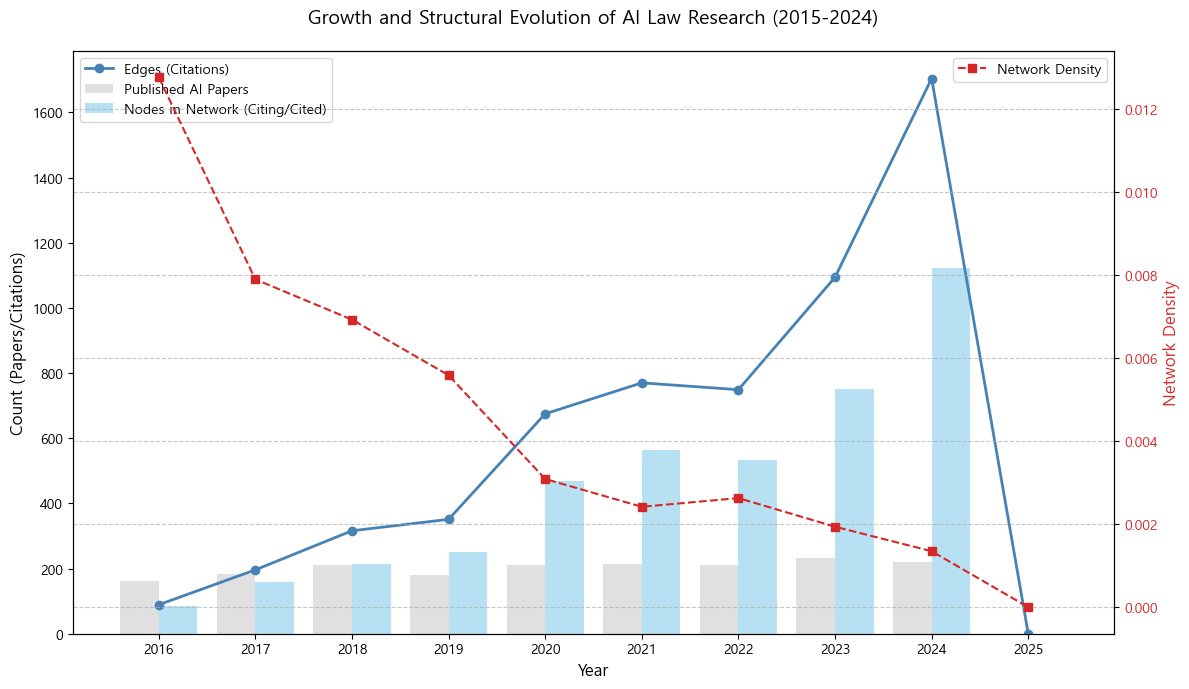

In [21]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. 분석 결과 데이터 로드
df = pd.read_csv('연도별_분절분석_결과.csv')

# 2. 시각화 (이중 축 활용)
fig, ax1 = plt.subplots(figsize=(12, 7))

# 축 1: 발행논문수 및 네트워크 노드수 (Bar)
# 두 데이터를 나란히 보여주기 위해 바 차트를 겹치거나 나열할 수 있습니다.
ax1.bar(df['연도'] - 0.2, df['발행논문수'], width=0.4, color='lightgray', alpha=0.7, label='Published AI Papers')
ax1.bar(df['연도'] + 0.2, df['네트워크_노드수'], width=0.4, color='skyblue', alpha=0.6, label='Nodes in Network (Citing/Cited)')

# 축 1: 엣지수 (Line) - 인용 관계의 총량
ax1.plot(df['연도'], df['엣지수'], color='steelblue', marker='o', linewidth=2, label='Edges (Citations)')

ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Count (Papers/Citations)', fontsize=12)
ax1.set_xticks(df['연도'])
ax1.legend(loc='upper left')

# 축 2: 밀도 (Secondary Y-axis)
ax2 = ax1.twinx()
ax2.plot(df['연도'], df['밀도'], color='tab:red', marker='s', linestyle='--', label='Network Density')
ax2.set_ylabel('Network Density', color='tab:red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.legend(loc='upper right')

# 그래프 제목 및 설정
plt.title('Growth and Structural Evolution of AI Law Research (2015-2024)', fontsize=14, pad=20)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 레이아웃 조정 및 저장
plt.tight_layout()
plt.savefig('AI_law_discrete_trends_updated.png', dpi=300)
plt.show()

###

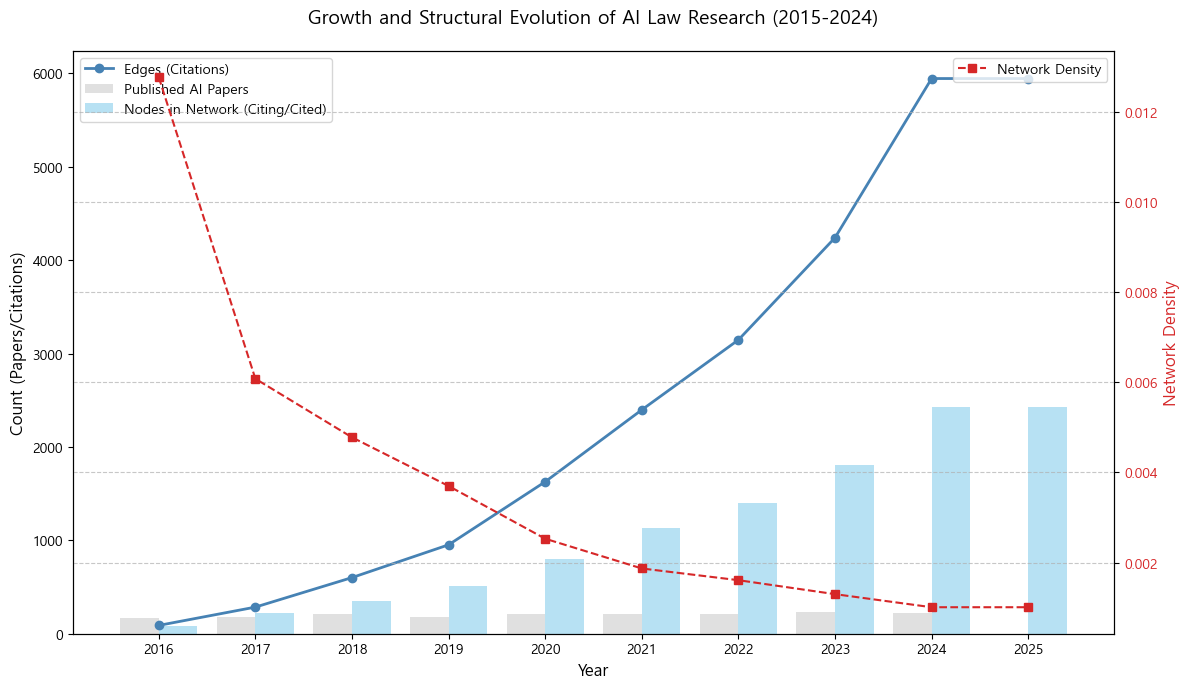

In [23]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. 분석 결과 데이터 로드
df = pd.read_csv('연도별_누적분석_결과.csv')

# 2. 시각화 (이중 축 활용)
fig, ax1 = plt.subplots(figsize=(12, 7))

# 축 1: 발행논문수 및 네트워크 노드수 (Bar)
# 두 데이터를 나란히 보여주기 위해 바 차트를 겹치거나 나열할 수 있습니다.
ax1.bar(df['연도'] - 0.2, df['발행논문수'], width=0.4, color='lightgray', alpha=0.7, label='Published AI Papers')
ax1.bar(df['연도'] + 0.2, df['네트워크_노드수'], width=0.4, color='skyblue', alpha=0.6, label='Nodes in Network (Citing/Cited)')

# 축 1: 엣지수 (Line) - 인용 관계의 총량
ax1.plot(df['연도'], df['엣지수'], color='steelblue', marker='o', linewidth=2, label='Edges (Citations)')

ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Count (Papers/Citations)', fontsize=12)
ax1.set_xticks(df['연도'])
ax1.legend(loc='upper left')

# 축 2: 밀도 (Secondary Y-axis)
ax2 = ax1.twinx()
ax2.plot(df['연도'], df['밀도'], color='tab:red', marker='s', linestyle='--', label='Network Density')
ax2.set_ylabel('Network Density', color='tab:red', fontsize=12)
ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.legend(loc='upper right')

# 그래프 제목 및 설정
plt.title('Growth and Structural Evolution of AI Law Research (2015-2024)', fontsize=14, pad=20)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 레이아웃 조정 및 저장
plt.tight_layout()
plt.savefig('AI_law_discrete_trends_updated.png', dpi=300)
plt.show()

# 개별 분석 시작

## 발행연도 상관 없이 특정 연도까지 인용된 모든 논문

In [24]:
import pandas as pd
import networkx as nx
import community.community_louvain as louvain
import os
from tqdm import tqdm
from collections import Counter

# 1. 환경 설정
OUTPUT_DIR = '01_AI_누적_지식_기반_분석'
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# 2. 데이터 로드
print("데이터를 로드하는 중...")
# 우리가 앞에서 만든 파일명으로 지정합니다.
nodes = pd.read_csv('legal_citation_nodes.csv')
edges = pd.read_csv('legal_citation_edges.csv')

# ID와 Year 타입을 문자열/숫자로 명확히 통일
nodes['Id'] = nodes['Id'].astype(str)
edges['Source'] = edges['Source'].astype(str)
edges['Target'] = edges['Target'].astype(str)
nodes['Year'] = pd.to_numeric(nodes['Year'], errors='coerce')

# 엣지에 발행연도 매칭 (인용한 논문의 연도 기준)
edges_with_year = edges.merge(nodes[['Id', 'Year']], left_on='Source', right_on='Id', how='left')
edges_with_year = edges_with_year.rename(columns={'Year': 'Source_Year'}).drop(columns=['Id'])

def run_cumulative_intellectual_base_tracking(start_year=2016, end_year=2025):
    for year in tqdm(range(start_year, end_year + 1), desc="연도별 누적 분석 진행 중"):
        # [핵심] 기준 연도 이하에 발행된 논문들이 생성한 모든 엣지 누적 추출
        cum_edges = edges_with_year[edges_with_year['Source_Year'] <= year]
        
        if cum_edges.empty:
            continue
            
        # 그래프 생성 (방향성)
        G_dir = nx.DiGraph()
        G_dir.add_edges_from(zip(cum_edges['Source'], cum_edges['Target']))
        
        # 커뮤니티 탐지 (Louvain은 무방향 그래프 기준이므로 변환)
        G_undir = G_dir.to_undirected()
        partition = louvain.best_partition(G_undir)
        
        # 지표 계산
        comm_counts = Counter(partition.values())
        # 가장 규모가 큰 상위 5개 커뮤니티 추출
        top_5_communities = [comm[0] for comm in comm_counts.most_common(5)]
        in_degrees = dict(G_dir.in_degree())
        
        year_data = []
        for comm_rank, comm_id in enumerate(top_5_communities, 1):
            # 해당 커뮤니티 소속 노드들
            comm_nodes = [n for n, c in partition.items() if c == comm_id]
            
            # 커뮤니티 내 논문들을 피인용수(In-degree) 기준으로 정렬
            comm_papers_sorted = sorted(
                [(n, in_degrees.get(n, 0)) for n in comm_nodes],
                key=lambda x: x[1],
                reverse=True
            )[:5] # 상위 5개 논문
            
            for paper_rank, (node_id, citation_count) in enumerate(comm_papers_sorted, 1):
                paper_info = nodes[nodes['Id'] == node_id]
                
                if not paper_info.empty:
                    # '저자' 컬럼이 노드 파일에 없을 수 있으므로 안전하게 처리
                    author = paper_info['저자'].values[0] if '저자' in paper_info.columns else "정보 없음"
                    
                    year_data.append({
                        '연도': year,
                        '커뮤니티_순위': comm_rank,
                        '커뮤니티_ID': comm_id,
                        '커뮤니티_크기': comm_counts[comm_id],
                        '논문_순위': paper_rank,
                        '인용수': citation_count,
                        '제목': paper_info['Label'].values[0],
                        '저자': author,
                        '발행연도': paper_info['Year'].values[0],
                        'Id': node_id
                    })
        
        # 연도별 결과 저장
        if year_data:
            year_df = pd.DataFrame(year_data)
            file_path = os.path.join(OUTPUT_DIR, f"cumulative_{year}.csv")
            year_df.to_csv(file_path, index=False, encoding='utf-8-sig')

if __name__ == "__main__":
    run_cumulative_intellectual_base_tracking()
    print(f"\n✅ 누적 지식 기반 분석 완료! '{OUTPUT_DIR}' 폴더 내 CSV 파일들을 확인하세요.")

데이터를 로드하는 중...


연도별 누적 분석 진행 중: 100%|██████████| 10/10 [00:00<00:00, 16.11it/s]


✅ 누적 지식 기반 분석 완료! '01_AI_누적_지식_기반_분석' 폴더 내 CSV 파일들을 확인하세요.


## 발행연도 상관 없이 특정 연도에 인용된 모든 논문

In [25]:
import pandas as pd
import networkx as nx
import community.community_louvain as louvain
import os
from tqdm import tqdm
from collections import Counter

# 1. 환경 설정
OUTPUT_DIR = '02_AI_시점별_담론_지형_분석'
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# 2. 데이터 로드
print("데이터를 로드하는 중...")
nodes = pd.read_csv('legal_citation_nodes.csv')
edges = pd.read_csv('legal_citation_edges.csv')

# ID 및 연도 데이터 타입 정제
nodes['Id'] = nodes['Id'].astype(str)
edges['Source'] = edges['Source'].astype(str)
edges['Target'] = edges['Target'].astype(str)
nodes['Year'] = pd.to_numeric(nodes['Year'], errors='coerce')

# 엣지에 발행연도 매칭 (인용을 수행한 'Source' 논문의 발행연도 기준)
edges_with_year = edges.merge(nodes[['Id', 'Year']], left_on='Source', right_on='Id', how='left')
edges_with_year = edges_with_year.rename(columns={'Year': 'Source_Year'}).drop(columns=['Id'])

def run_snapshot_discourse_tracking(start_year=2016, end_year=2025):
    for year in tqdm(range(start_year, end_year + 1), desc="연도별 스냅샷 분석 진행 중"):
        # [핵심 로직] 오직 해당 연도(year)에 발행된 논문들이 생성한 엣지만 추출
        # 당해 연도의 연구자들이 '선택한 지식'의 지형도를 그립니다.
        snapshot_edges = edges_with_year[edges_with_year['Source_Year'] == year]
        
        if snapshot_edges.empty:
            continue
            
        # 그래프 생성 (방향성 그래프)
        G_dir = nx.DiGraph()
        G_dir.add_edges_from(zip(snapshot_edges['Source'], snapshot_edges['Target']))
        
        # 커뮤니티 탐지 (무방향 그래프로 변환 후 Louvain 알고리즘 적용)
        G_undir = G_dir.to_undirected()
        partition = louvain.best_partition(G_undir)
        
        # 지표 계산
        comm_counts = Counter(partition.values())
        top_5_communities = [comm[0] for comm in comm_counts.most_common(5)]
        in_degrees = dict(G_dir.in_degree())
        
        year_data = []
        for comm_rank, comm_id in enumerate(top_5_communities, 1):
            comm_nodes = [n for n, c in partition.items() if c == comm_id]
            
            # 당해 연도 피인용수(In-degree) 기준으로 정렬
            comm_papers_sorted = sorted(
                [(n, in_degrees.get(n, 0)) for n in comm_nodes],
                key=lambda x: x[1],
                reverse=True
            )[:5]
            
            for paper_rank, (node_id, citation_count) in enumerate(comm_papers_sorted, 1):
                paper_info = nodes[nodes['Id'] == node_id]
                if not paper_info.empty:
                    # '저자' 컬럼 존재 여부 확인 (없을 경우 대비)
                    author = paper_info['저자'].values[0] if '저자' in paper_info.columns else "정보 없음"
                    
                    year_data.append({
                        '분석연도': year,
                        '커뮤니티_순위': comm_rank,
                        '커뮤니티_ID': comm_id,
                        '커뮤니티_크기': comm_counts[comm_id],
                        '논문_순위': paper_rank,
                        '인용수(당해)': citation_count,
                        '제목': paper_info['Label'].values[0],
                        '저자': author,
                        '원래_발행연도': paper_info['Year'].values[0],
                        'Id': node_id
                    })
        
        # 결과 저장
        if year_data:
            year_df = pd.DataFrame(year_data)
            file_path = os.path.join(OUTPUT_DIR, f"snapshot_{year}.csv")
            year_df.to_csv(file_path, index=False, encoding='utf-8-sig')

if __name__ == "__main__":
    run_snapshot_discourse_tracking()
    print(f"\n✨ 시점별 담론 분석 완료! '{OUTPUT_DIR}' 폴더에서 연도별 스냅샷을 확인하세요.")

데이터를 로드하는 중...


연도별 스냅샷 분석 진행 중: 100%|██████████| 10/10 [00:00<00:00, 46.00it/s]


✨ 시점별 담론 분석 완료! '02_AI_시점별_담론_지형_분석' 폴더에서 연도별 스냅샷을 확인하세요.


## 특정 연도에 발행한 논문의 중 피인용 횟수 기준

In [26]:
import pandas as pd
import networkx as nx
import community.community_louvain as louvain
import os
from tqdm import tqdm
from collections import Counter

# 1. 환경 설정
OUTPUT_DIR = '03_AI_연도별_신성_담론_분석'
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# 2. 데이터 로드
print("데이터를 로드하는 중...")
nodes = pd.read_csv('legal_citation_nodes.csv')
edges = pd.read_csv('legal_citation_edges.csv')

# ID 및 연도 데이터 타입 정제
nodes['Id'] = nodes['Id'].astype(str)
edges['Source'] = edges['Source'].astype(str)
edges['Target'] = edges['Target'].astype(str)
nodes['Year'] = pd.to_numeric(nodes['Year'], errors='coerce')

def run_rising_star_paper_tracking(start_year=2016, end_year=2025):
    print("전체 기간 통합 네트워크 분석 중 (글로벌 지식 구조 식별)...")
    
    # [핵심 로직] 전체 기간의 모든 엣지를 사용하여 글로벌 위상 계산
    G_total = nx.DiGraph()
    G_total.add_edges_from(zip(edges['Source'], edges['Target']))
    
    # 1. 전체 네트워크에서의 누적 피인용수(Global In-degree) 계산
    global_in_degrees = dict(G_total.in_degree())
    
    # 2. 전체 네트워크에서의 커뮤니티 탐지 (지식의 거대한 줄기 파악)
    G_undir = G_total.to_undirected()
    global_partition = louvain.best_partition(G_undir)
    global_comm_counts = Counter(global_partition.values())

    for year in tqdm(range(start_year, end_year + 1), desc="연도별 발행작 분석 진행 중"):
        # [핵심 로직] 오직 해당 연도(year)에 '발행된' 논문들만 추출
        year_born_papers = nodes[nodes['Year'] == year].copy()
        
        if year_born_papers.empty:
            continue
            
        # 글로벌 지표 결합 (전체 기간 동안 받은 인용수와 소속된 대규모 커뮤니티 매핑)
        year_born_papers['인용수_전체'] = year_born_papers['Id'].map(global_in_degrees).fillna(0)
        year_born_papers['커뮤니티_ID'] = year_born_papers['Id'].map(global_partition)
        
        # 해당 연도 발행작들이 가장 많이 속해 있는 상위 5개 글로벌 커뮤니티 식별
        # (그해 발행된 논문들이 주로 어떤 학문적 줄기에 기여했는지 확인)
        top_5_comms = year_born_papers['커뮤니티_ID'].value_counts().head(5).index
        
        year_data = []
        for comm_rank, comm_id in enumerate(top_5_comms, 1):
            # 해당 연도 발행 + 특정 글로벌 커뮤니티 소속 논문 필터링
            comm_papers = year_born_papers[year_born_papers['커뮤니티_ID'] == comm_id]
            
            # 전체 피인용수 기준으로 정렬 (해당 연도 출생 논문 중 가장 영향력 있는 '신성' 식별)
            top_5_papers = comm_papers.sort_values(by='인용수_전체', ascending=False).head(5)
            
            for paper_rank, (_, row) in enumerate(top_5_papers.iterrows(), 1):
                # '저자' 컬럼 예외 처리
                author = row['저자'] if '저자' in row else "정보 없음"
                
                year_data.append({
                    '분석연도(출생년도)': year,
                    '커뮤니티_순위': comm_rank,
                    '커뮤니티_ID': comm_id,
                    '커뮤니티_전체크기': global_comm_counts[comm_id],
                    '논문_순위': paper_rank,
                    '누적_인용수': row['인용수_전체'],
                    '제목': row['Label'],
                    '저자': author,
                    'Id': row['Id']
                })
        
        # 결과 저장
        if year_data:
            year_df = pd.DataFrame(year_data)
            file_path = os.path.join(OUTPUT_DIR, f"rising_stars_{year}.csv")
            year_df.to_csv(file_path, index=False, encoding='utf-8-sig')

if __name__ == "__main__":
    run_rising_star_paper_tracking()
    print(f"\n🌟 연도별 신성 담론 분석 완료! '{OUTPUT_DIR}' 폴더를 확인하세요.")

데이터를 로드하는 중...
전체 기간 통합 네트워크 분석 중 (글로벌 지식 구조 식별)...


연도별 발행작 분석 진행 중: 100%|██████████| 10/10 [00:00<00:00, 224.53it/s]


🌟 연도별 신성 담론 분석 완료! '03_AI_연도별_신성_담론_분석' 폴더를 확인하세요.


## 특정 연도에 발행한 논문의 중 피인용 횟수 기준 2년 이내

In [27]:
import pandas as pd
import networkx as nx
import community.community_louvain as louvain
import os
from tqdm import tqdm
from collections import Counter

# 1. 환경 설정
OUTPUT_DIR = '04_AI_최신_연구_전선_분석'
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# 2. 데이터 로드
print("데이터를 로드하는 중...")
nodes = pd.read_csv('legal_citation_nodes.csv')
edges = pd.read_csv('legal_citation_edges.csv')

# ID 및 연도 데이터 타입 정제
nodes['Id'] = nodes['Id'].astype(str)
edges['Source'] = edges['Source'].astype(str)
edges['Target'] = edges['Target'].astype(str)
nodes['Year'] = pd.to_numeric(nodes['Year'], errors='coerce')

# 엣지에 Source(인용한 논문)와 Target(인용된 논문)의 발행연도를 모두 매칭
# 1. Source(인용한 논문)의 연도 매칭
edges_meta = edges.merge(nodes[['Id', 'Year']], left_on='Source', right_on='Id', how='left')
edges_meta = edges_meta.rename(columns={'Year': 'source_year'}).drop(columns=['Id'])

# 2. Target(인용된 논문)의 연도 매칭
edges_meta = edges_meta.merge(nodes[['Id', 'Year']], left_on='Target', right_on='Id', how='left')
edges_meta = edges_meta.rename(columns={'Year': 'target_year'}).drop(columns=['Id'])

def run_research_front_tracking(start_year=2016, end_year=2025):
    for year in tqdm(range(start_year, end_year + 1), desc="연구 전선 분석 진행 중"):
        # [핵심 로직] 연구 전선 정의:
        # 1. 인용 대상(Target)이 분석 연도(year)에 발행됨
        # 2. 인용한 논문(Source)이 발행 당해 또는 다음 해(year ~ year+1)에 신속히 인용함
        mask_front = (edges_meta['target_year'] == year) & \
                     (edges_meta['source_year'] >= year) & \
                     (edges_meta['source_year'] <= year + 1)
        
        front_edges = edges_meta[mask_front]
        
        if front_edges.empty:
            continue
            
        # 그래프 생성 (방향성)
        G_dir = nx.DiGraph()
        G_dir.add_edges_from(zip(front_edges['Source'], front_edges['Target']))
        
        # 커뮤니티 탐지 (무방향 변환 후 Louvain)
        G_undir = G_dir.to_undirected()
        partition = louvain.best_partition(G_undir)
        
        # 지표 계산
        comm_counts = Counter(partition.values())
        top_5_communities = [comm[0] for comm in comm_counts.most_common(5)]
        in_degrees = dict(G_dir.in_degree())
        
        year_data = []
        for comm_rank, comm_id in enumerate(top_5_communities, 1):
            comm_nodes = [n for n, c in partition.items() if c == comm_id]
            
            # 단기 피인용수(2년 내 인용) 기준으로 정렬
            comm_papers_sorted = sorted(
                [(n, in_degrees.get(n, 0)) for n in comm_nodes if n in in_degrees],
                key=lambda x: x[1],
                reverse=True
            )[:5]
            
            for paper_rank, (node_id, citation_count) in enumerate(comm_papers_sorted, 1):
                paper_info = nodes[nodes['Id'] == node_id]
                if not paper_info.empty:
                    # '저자' 컬럼 예외 처리
                    author = paper_info['저자'].values[0] if '저자' in paper_info.columns else "정보 없음"
                    
                    year_data.append({
                        '기준연도': year,
                        '커뮤니티_순위': comm_rank,
                        '커뮤니티_ID': comm_id,
                        '커뮤니티_크기': comm_counts[comm_id],
                        '논문_순위': paper_rank,
                        '단기_인용수(2년)': citation_count,
                        '제목': paper_info['Label'].values[0],
                        '저자': author,
                        '발행연도': paper_info['Year'].values[0],
                        'Id': node_id
                    })
        
        # 결과 저장
        if year_data:
            year_df = pd.DataFrame(year_data)
            file_path = os.path.join(OUTPUT_DIR, f"research_front_{year}.csv")
            year_df.to_csv(file_path, index=False, encoding='utf-8-sig')

if __name__ == "__main__":
    run_research_front_tracking()
    print(f"\n✅ 최신 연구 전선 분석 완료! '{OUTPUT_DIR}' 폴더를 확인하세요.")

데이터를 로드하는 중...


연구 전선 분석 진행 중: 100%|██████████| 10/10 [00:00<00:00, 82.47it/s]


✅ 최신 연구 전선 분석 완료! '04_AI_최신_연구_전선_분석' 폴더를 확인하세요.


### 엑셀 컴바인

In [ ]:
import pandas as pd
import os

# 1. CSV 파일들이 있는 폴더 경로 설정
folder_path = './03_AI_연도별_신성_담론_분석'  # CSV 파일이 저장된 폴더명으로 수정하세요
output_file = '03_AI_연도별_신성_담론_분석.xlsx'

# 2. ExcelWriter 객체 생성
with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    # 폴더 내의 모든 파일 확인
    for file_name in os.listdir(folder_path):
        if file_name.endswith('.csv'):
            # 파일 경로 생성
            file_path = os.path.join(folder_path, file_name)
            
            # CSV 읽기 (인코딩 문제는 필요시 encoding='cp949' 추가)
            df = pd.read_csv(file_path)
            
            # 시트 이름 설정 (파일명에서 .csv 제외, 최대 31자 제한 준수)
            sheet_name = file_name[:-4][:31]
            
            # 엑셀 시트로 쓰기
            df.to_excel(writer, sheet_name=sheet_name, index=False)

print(f"합치기 완료! 생성된 파일: {output_file}")

### MPA 분석

In [ ]:
import pandas as pd
import networkx as nx
import time

# 1. 데이터 로드
print("1/5. 데이터 로딩 중...")
nodes = pd.read_csv('KCI_AI_전용_논문_노드.csv')
edges = pd.read_csv('KCI_AI_전용_인용_엣지.csv')

# --- [추가] 연도 범위 설정 라인 ---
start_year = 2015  # 시작 연도
end_year = 2024    # 종료 연도

# 설정한 범위에 해당하는 노드만 필터링
nodes = nodes[(nodes['발행연도'] >= start_year) & (nodes['발행연도'] <= end_year)]

# 필터링된 노드들에 속한 엣지만 남기기
valid_node_ids = set(nodes['node_id'])
edges = edges[edges['source_id'].isin(valid_node_ids) & edges['target_id_final'].isin(valid_node_ids)]

# 2. 방향성 그래프 생성
G = nx.DiGraph()
G.add_edges_from(zip(edges['source_id'], edges['target_id_final']))

# [수정] 사이클 제거 로직 강화
if not nx.is_directed_acyclic_graph(G):
    print("⚠️ 사이클(Cycle)이 감지되어 제거를 시작합니다.")
    while not nx.is_directed_acyclic_graph(G):
        try:
            # 사이클을 하나 찾아 그 중 첫 번째 엣지를 제거
            cycle = nx.find_cycle(G, orientation='original')
            G.remove_edge(cycle[0][0], cycle[0][1])
        except nx.NetworkXNoCycle:
            break
    print("✅ 모든 사이클 제거 완료.")

def calculate_spc_optimized(G):
    """위상 정렬을 이용한 O(V+E) SPC 가중치 계산"""
    topo_order = list(nx.topological_sort(G))
    
    f = {n: 0 for n in G.nodes()}
    for n in topo_order:
        if G.in_degree(n) == 0:
            f[n] = 1
        for successor in G.successors(n):
            f[successor] += f[n]
            
    b = {n: 0 for n in G.nodes()}
    for n in reversed(topo_order):
        if G.out_degree(n) == 0:
            b[n] = 1
        for predecessor in G.predecessors(n):
            b[predecessor] += b[n]
            
    edge_spc = {(u, v): f[u] * b[v] for u, v in G.edges()}
    return edge_spc

def extract_main_path(G, edge_weights):
    if not edge_weights: return []
    
    # 1. 최고 가중치 엣지 탐색
    max_e = max(edge_weights, key=edge_weights.get)
    path = [max_e]
    
    # 2. Forward (Sink 방향)
    curr = max_e[1]
    while G.out_degree(curr) > 0:
        out_edges = list(G.out_edges(curr))
        # 가중치가 있는 엣지만 선별하여 그 중 최대값 선택
        valid_out_edges = [e for e in out_edges if e in edge_weights]
        if not valid_out_edges: break
        nxt_e = max(valid_out_edges, key=lambda e: edge_weights[e])
        path.append(nxt_e)
        curr = nxt_e[1]
        
    # 3. Backward (Source 방향)
    curr = max_e[0]
    while G.in_degree(curr) > 0:
        in_edges = list(G.in_edges(curr))
        valid_in_edges = [e for e in in_edges if e in edge_weights]
        if not valid_in_edges: break
        prev_e = max(valid_in_edges, key=lambda e: edge_weights[e])
        path.insert(0, prev_e)
        curr = prev_e[0]
        
    return path

# 3. 실행
start_time = time.time()
print("2/5. SPC 가중치 계산 중...")
edge_weights = calculate_spc_optimized(G)

print("3/5. 주경로 추출 중...")
main_path_edges = extract_main_path(G, edge_weights)

# 4. 결과 정리
path_node_ids = []
for u, v in main_path_edges:
    if u not in path_node_ids: path_node_ids.append(u)
    if v not in path_node_ids: path_node_ids.append(v)

main_path_info = pd.DataFrame({'node_id': path_node_ids}).merge(
    nodes[['node_id', '제목', '저자', '발행연도']], on='node_id', how='left'
)

print(f"\n✅ 분석 완료! (소요시간: {time.time() - start_time:.2f}초)")
print("\n🏆 추출된 주경로 논문 리스트:")
print(main_path_info[['발행연도', '제목', '저자']])

# 5. 저장
main_path_info.to_csv('AI법학_최종_주경로_결과.csv', index=False, encoding='utf-8-sig')